In [ ]:
import requests
import pandas as pd

In [ ]:
url = "https://api.github.com/search/repositories?q=machine+learning&sort=stars&order=desc&per_page=100"

response = requests.get(url)

data = response.json()

print(response.status_code)

200


In [ ]:
df = pd.DataFrame(data["items"])

df.head()

,id,node_id,name,full_name,private,owner,html_url,description,fork,url,...,web_commit_signoff_required,has_pull_requests,pull_request_creation_policy,topics,visibility,forks,open_issues,watchers,default_branch,score
0,45717250,MDEwOlJlcG9zaXRvcnk0NTcxNzI1MA==,tensorflow,tensorflow/tensorflow,False,"{'login': 'tensorflow', 'id': 15658638, 'node_...",https://github.com/tensorflow/tensorflow,An Open Source Machine Learning Framework for ...,False,https://api.github.com/repos/tensorflow/tensor...,...,False,True,all,"[deep-learning, deep-neural-networks, distribu...",public,76044,2919,196990,master,1.0
1,155220641,MDEwOlJlcG9zaXRvcnkxNTUyMjA2NDE=,transformers,huggingface/transformers,False,"{'login': 'huggingface', 'id': 25720743, 'node...",https://github.com/huggingface/transformers,🤗 Transformers: the model-definition framework...,False,https://api.github.com/repos/huggingface/trans...,...,False,True,all,"[audio, deep-learning, deepseek, gemma, glm, h...",public,34260,2388,164196,main,1.0
2,343965132,MDEwOlJlcG9zaXRvcnkzNDM5NjUxMzI=,ML-For-Beginners,microsoft/ML-For-Beginners,False,"{'login': 'microsoft', 'id': 6154722, 'node_id...",https://github.com/microsoft/ML-For-Beginners,"12 weeks, 26 lessons, 52 quizzes, classic Mach...",False,https://api.github.com/repos/microsoft/ML-For-...,...,False,True,all,"[data-science, education, machine-learning, ma...",public,21956,11,89460,main,1.0
3,145553672,MDEwOlJlcG9zaXRvcnkxNDU1NTM2NzI=,funNLP,fighting41love/funNLP,False,"{'login': 'fighting41love', 'id': 11475294, 'n...",https://github.com/fighting41love/funNLP,中英文敏感词、语言检测、中外手机/电话归属地/运营商查询、名字推断性别、手机号抽取、身份证抽...,False,https://api.github.com/repos/fighting41love/fu...,...,False,True,all,[],public,15267,53,82513,master,1.0
4,21872392,MDEwOlJlcG9zaXRvcnkyMTg3MjM5Mg==,awesome-machine-learning,josephmisiti/awesome-machine-learning,False,"{'login': 'josephmisiti', 'id': 246302, 'node_...",https://github.com/josephmisiti/awesome-machin...,A curated list of awesome Machine Learning fra...,False,https://api.github.com/repos/josephmisiti/awes...,...,False,True,all,[],public,15608,24,74044,master,1.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype              
---  ------        --------------  -----              
 0   name          100 non-null    object             
 1   owner         100 non-null    object             
 2   language      100 non-null    object             
 3   stars         100 non-null    int64              
 4   forks         100 non-null    int64              
 5   watchers      100 non-null    int64              
 6   open_issues   100 non-null    int64              
 7   created_date  100 non-null    datetime64[ns, UTC]
 8   updated_date  100 non-null    datetime64[ns, UTC]
 9   license       100 non-null    object             
 10  created_year  100 non-null    int32              
dtypes: datetime64[ns, UTC](2), int32(1), int64(4), object(4)
memory usage: 8.3+ KB


In [ ]:
df.shape

(100, 11)

In [ ]:
df.columns

Index(['name', 'owner', 'language', 'stars', 'forks', 'watchers',
       'open_issues', 'created_date', 'updated_date', 'license',
       'created_year'],
      dtype='object')

In [ ]:
df = df[
    [
        "name",
        "owner",
        "language",
        "stargazers_count",
        "forks_count",
        "watchers_count",
        "open_issues_count",
        "created_at",
        "updated_at",
        "license"
    ]
]

df.head()

,name,owner,language,stargazers_count,forks_count,watchers_count,open_issues_count,created_at,updated_at,license
0,tensorflow,"{'login': 'tensorflow', 'id': 15658638, 'node_...",C++,196990,76044,196990,2919,2015-11-07T01:19:20Z,2026-08-17T23:00:04Z,"{'key': 'apache-2.0', 'name': 'Apache License ..."
1,transformers,"{'login': 'huggingface', 'id': 25720743, 'node...",Python,164196,34260,164196,2388,2018-10-29T13:56:00Z,2026-08-18T00:11:59Z,"{'key': 'apache-2.0', 'name': 'Apache License ..."
2,ML-For-Beginners,"{'login': 'microsoft', 'id': 6154722, 'node_id...",Jupyter Notebook,89460,21956,89460,11,2021-03-03T01:34:05Z,2026-08-17T23:45:31Z,"{'key': 'mit', 'name': 'MIT License', 'spdx_id..."
3,funNLP,"{'login': 'fighting41love', 'id': 11475294, 'n...",Python,82513,15267,82513,53,2018-08-21T11:20:39Z,2026-08-17T18:29:06Z,None
4,awesome-machine-learning,"{'login': 'josephmisiti', 'id': 246302, 'node_...",Python,74044,15608,74044,24,2014-07-15T19:11:19Z,2026-08-18T00:15:07Z,"{'key': 'other', 'name': 'Other', 'spdx_id': '..."


In [ ]:
df["owner"] = df["owner"].apply(lambda x: x["login"] if x else None)

TypeError: string indices must be integers, not 'str'

In [ ]:
df["license"] = df["license"].apply(lambda x: x["name"] if x else None)

In [ ]:
df.isnull().sum()

,0
name,0
owner,0
language,23
stargazers_count,0
forks_count,0
watchers_count,0
open_issues_count,0
created_at,0
updated_at,0
license,22


In [ ]:
df["language"] = df["language"].fillna("Unknown")
df["license"] = df["license"].fillna("No License")

In [ ]:
df.isnull().sum()

,0
name,0
owner,0
language,0
stargazers_count,0
forks_count,0
watchers_count,0
open_issues_count,0
created_at,0
updated_at,0
license,0


In [ ]:
df.duplicated().sum()

In [ ]:
df["created_at"] = pd.to_datetime(df["created_at"])
df["updated_at"] = pd.to_datetime(df["updated_at"])

In [ ]:
df = df.rename(
    columns={
        "stargazers_count": "stars",
        "forks_count": "forks",
        "watchers_count": "watchers",
        "open_issues_count": "open_issues",
        "created_at": "created_date",
        "updated_at": "updated_date"
    }
)

In [ ]:
df.head()

In [ ]:
df.info()

In [ ]:
df.isnull().sum()

In [ ]:
df.duplicated().sum()

In [ ]:
df.shape

In [ ]:
df.to_csv("github_projects.csv", index=False)

In [ ]:
pd.read_csv("github_projects.csv").head()

In [ ]:
import sqlite3

In [ ]:
conn = sqlite3.connect("github_projects.db")

In [ ]:
df.to_sql("Repositories", conn, if_exists="replace", index=False)

100

In [ ]:
query = """
SELECT *
FROM Repositories
LIMIT 5;
"""

pd.read_sql_query(query, conn)

,name,owner,language,stars,forks,watchers,open_issues,created_date,updated_date,license,created_year
0,tensorflow,tensorflow,C++,196990,76044,196990,2919,2015-11-07 01:19:20+00:00,2026-08-17 23:00:04+00:00,Apache License 2.0,2015
1,transformers,huggingface,Python,164196,34260,164196,2388,2018-10-29 13:56:00+00:00,2026-08-18 00:11:59+00:00,Apache License 2.0,2018
2,ML-For-Beginners,microsoft,Jupyter Notebook,89460,21956,89460,11,2021-03-03 01:34:05+00:00,2026-08-17 23:45:31+00:00,MIT License,2021
3,funNLP,fighting41love,Python,82513,15267,82513,53,2018-08-21 11:20:39+00:00,2026-08-17 18:29:06+00:00,No License,2018
4,awesome-machine-learning,josephmisiti,Python,74044,15608,74044,24,2014-07-15 19:11:19+00:00,2026-08-18 00:15:07+00:00,Other,2014


In [ ]:
query = """
SELECT *
FROM Repositories
WHERE stars > 10000;
"""

pd.read_sql_query(query, conn)

,name,owner,language,stars,forks,watchers,open_issues,created_date,updated_date,license,created_year
0,tensorflow,tensorflow,C++,196990,76044,196990,2919,2015-11-07 01:19:20+00:00,2026-08-17 23:00:04+00:00,Apache License 2.0,2015
1,transformers,huggingface,Python,164196,34260,164196,2388,2018-10-29 13:56:00+00:00,2026-08-18 00:11:59+00:00,Apache License 2.0,2018
2,ML-For-Beginners,microsoft,Jupyter Notebook,89460,21956,89460,11,2021-03-03 01:34:05+00:00,2026-08-17 23:45:31+00:00,MIT License,2021
3,funNLP,fighting41love,Python,82513,15267,82513,53,2018-08-21 11:20:39+00:00,2026-08-17 18:29:06+00:00,No License,2018
4,awesome-machine-learning,josephmisiti,Python,74044,15608,74044,24,2014-07-15 19:11:19+00:00,2026-08-18 00:15:07+00:00,Other,2014
...,...,...,...,...,...,...,...,...,...,...,...
65,machine-learning-systems-design,chiphuyen,HTML,10525,1631,10525,11,2019-11-24 23:16:28+00:00,2026-08-17 23:25:04+00:00,No License,2019
66,Machine-Learning,Jack-Cherish,Python,10370,5065,10370,7,2017-03-25 07:32:37+00:00,2026-08-17 18:03:13+00:00,No License,2017
67,machine-learning-notes,roboticcam,Jupyter Notebook,10330,1825,10330,28,2018-02-15 15:42:33+00:00,2026-08-17 03:40:29+00:00,No License,2018
68,3D-Machine-Learning,timzhang642,Unknown,10194,1797,10194,21,2017-08-12 15:20:54+00:00,2026-08-17 12:16:16+00:00,No License,2017


In [ ]:
query = """
SELECT *
FROM Repositories
WHERE name LIKE '%Machine%';
"""

pd.read_sql_query(query, conn)

,name,owner,language,stars,forks,watchers,open_issues,created_date,updated_date,license,created_year
0,awesome-machine-learning,josephmisiti,Python,74044,15608,74044,24,2014-07-15 19:11:19+00:00,2026-08-18 00:15:07+00:00,Other,2014
1,500-AI-Machine-learning-Deep-learning-Computer...,ashishpatel26,Unknown,36342,7440,36342,67,2021-01-02 12:08:37+00:00,2026-08-17 22:58:21+00:00,No License,2021
2,machine-learning-for-software-engineers,ZuzooVn,Unknown,28859,6148,28859,32,2016-10-09 21:20:25+00:00,2026-08-17 08:46:18+00:00,Creative Commons Attribution Share Alike 4.0 I...,2016
3,homemade-machine-learning,trekhleb,Jupyter Notebook,24759,4194,24759,31,2018-11-01 04:34:19+00:00,2026-08-17 04:12:18+00:00,MIT License,2018
4,awesome-production-machine-learning,EthicalML,Unknown,20852,2590,20852,31,2018-08-15 14:28:41+00:00,2026-08-17 20:46:44+00:00,MIT License,2018
5,machine-learning-for-trading,stefan-jansen,Jupyter Notebook,20494,5522,20494,6,2018-05-09 12:33:08+00:00,2026-08-17 23:01:22+00:00,MIT License,2018
6,stanford-cs-229-machine-learning,afshinea,Unknown,20119,4248,20119,20,2018-08-04 23:01:00+00:00,2026-08-17 22:24:48+00:00,MIT License,2018
7,Machine-Learning-Tutorials,ujjwalkarn,Unknown,18107,3970,18107,47,2015-09-12 14:51:38+00:00,2026-08-17 14:27:22+00:00,Creative Commons Zero v1.0 Universal,2015
8,machine-learning-zoomcamp,DataTalksClub,Jupyter Notebook,13930,3092,13930,3,2020-04-17 04:29:23+00:00,2026-08-17 22:25:57+00:00,No License,2020
9,machine-learning-interview,khangich,Unknown,12782,2043,12782,9,2020-08-11 06:26:32+00:00,2026-08-17 10:04:18+00:00,No License,2020


In [ ]:
query = """
SELECT name, stars, forks
FROM Repositories
WHERE stars > 10000
AND forks > 1000;
"""

pd.read_sql_query(query, conn)

,name,stars,forks
0,tensorflow,196990,76044
1,transformers,164196,34260
2,ML-For-Beginners,89460,21956
3,funNLP,82513,15267
4,awesome-machine-learning,74044,15608
...,...,...,...
64,machine-learning-systems-design,10525,1631
65,Machine-Learning,10370,5065
66,machine-learning-notes,10330,1825
67,3D-Machine-Learning,10194,1797


In [ ]:
query = """
SELECT name, language, stars
FROM Repositories
WHERE language = 'Python'
OR language = 'JavaScript';
"""

pd.read_sql_query(query, conn)

,name,language,stars
0,transformers,Python,164196
1,funNLP,Python,82513
2,awesome-machine-learning,Python,74044
3,scikit-learn,Python,66963
4,gradio,Python,43377
5,netron,JavaScript,33363
6,ML-From-Scratch,Python,32483
7,linkedin-skill-assessments-quizzes,Python,28813
8,cs249r_book,Python,27943
9,onnx,Python,21320


In [ ]:
query = """
SELECT name, language, stars
FROM Repositories
WHERE NOT language = 'Python';
"""

pd.read_sql_query(query, conn)

,name,language,stars
0,tensorflow,C++,196990
1,ML-For-Beginners,Jupyter Notebook,89460
2,500-AI-Machine-learning-Deep-learning-Computer...,Unknown,36342
3,C-Plus-Plus,C++,34582
4,netron,JavaScript,33363
...,...,...,...
65,Machine-learning-learning-notes,Unknown,7763
66,awesome-youtubers,Markdown,7691
67,Learn_Machine_Learning_in_3_Months,Unknown,7607
68,h2o-3,Jupyter Notebook,7494


In [ ]:
query = """
SELECT name, stars
FROM Repositories
ORDER BY stars DESC;
"""

pd.read_sql_query(query, conn)

,name,stars
0,tensorflow,196990
1,transformers,164196
2,ML-For-Beginners,89460
3,funNLP,82513
4,awesome-machine-learning,74044
...,...,...
95,Machine-learning-learning-notes,7763
96,awesome-youtubers,7691
97,Learn_Machine_Learning_in_3_Months,7607
98,h2o-3,7494


In [ ]:
query = """
SELECT name, stars
FROM Repositories
ORDER BY stars DESC
LIMIT 10;
"""

top_10 = pd.read_sql_query(query, conn)

top_10

,name,stars
0,tensorflow,196990
1,transformers,164196
2,ML-For-Beginners,89460
3,funNLP,82513
4,awesome-machine-learning,74044
5,scikit-learn,66963
6,gradio,43377
7,500-AI-Machine-learning-Deep-learning-Computer...,36342
8,C-Plus-Plus,34582
9,netron,33363


In [ ]:
query = """
SELECT name, stars
FROM Repositories
ORDER BY stars DESC
LIMIT 10;
"""

top_10 = pd.read_sql_query(query, conn)

top_10

,name,stars
0,tensorflow,196990
1,transformers,164196
2,ML-For-Beginners,89460
3,funNLP,82513
4,awesome-machine-learning,74044
5,scikit-learn,66963
6,gradio,43377
7,500-AI-Machine-learning-Deep-learning-Computer...,36342
8,C-Plus-Plus,34582
9,netron,33363


In [ ]:
query = """
SELECT AVG(stars) AS average_stars
FROM Repositories;
"""

pd.read_sql_query(query, conn)

,average_stars
0,20799.51


In [ ]:
query = """
SELECT language, COUNT(*) AS repository_count
FROM Repositories
GROUP BY language
HAVING COUNT(*) > 5
ORDER BY repository_count DESC;
"""

language_counts = pd.read_sql_query(query, conn)

language_counts

,language,repository_count
0,Python,30
1,Unknown,23
2,Jupyter Notebook,19
3,C++,12


In [ ]:
import matplotlib.pyplot as plt

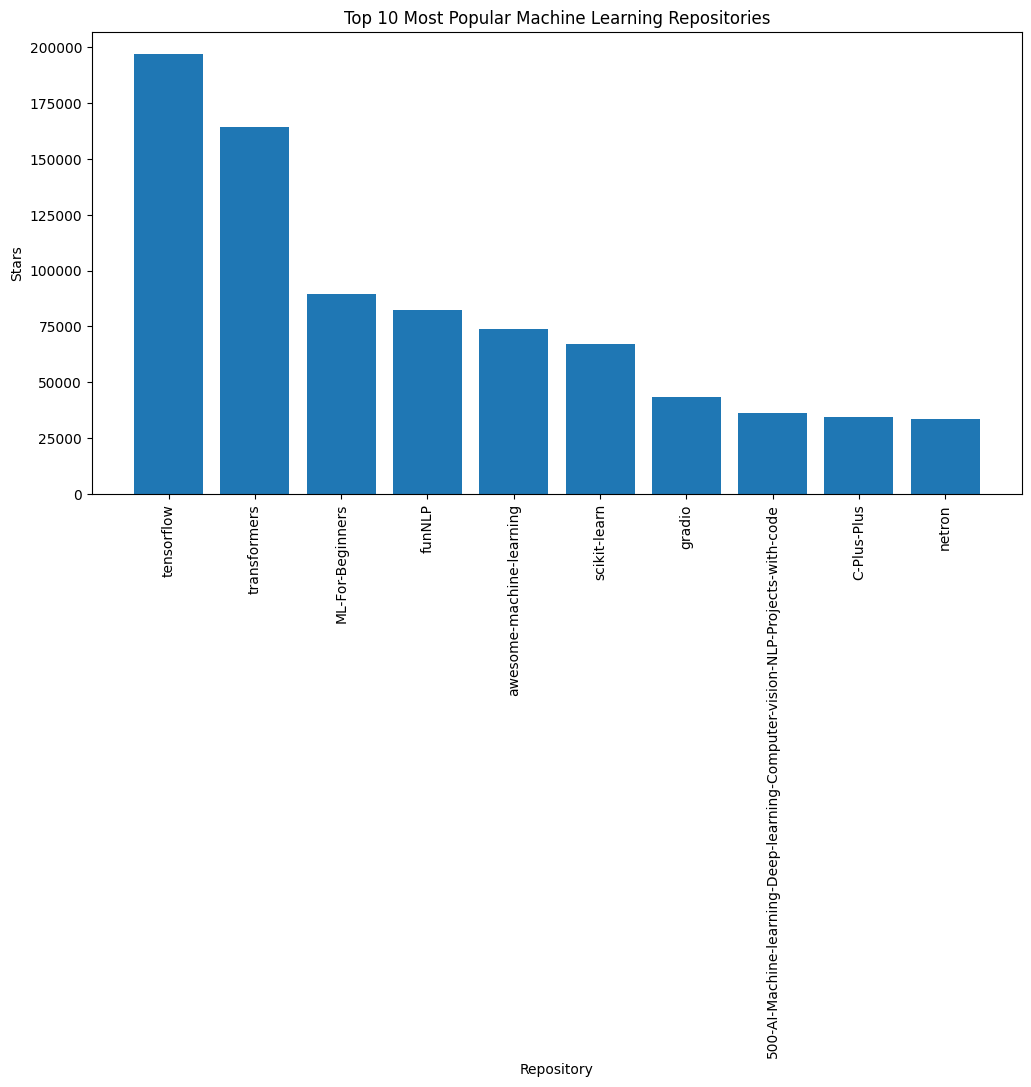

In [ ]:
plt.figure(figsize=(12, 6))

plt.bar(top_10["name"], top_10["stars"])

plt.xticks(rotation=90)
plt.xlabel("Repository")
plt.ylabel("Stars")
plt.title("Top 10 Most Popular Machine Learning Repositories")

plt.show()

In [ ]:
df["created_year"] = df["created_date"].dt.year

In [ ]:
creation_trends = (
    df.groupby("created_year")
    .size()
    .reset_index(name="repository_count")
)

creation_trends

,created_year,repository_count
0,2009,1
1,2010,2
2,2011,2
3,2013,3
4,2014,6
5,2015,7
6,2016,14
7,2017,17
8,2018,18
9,2019,7


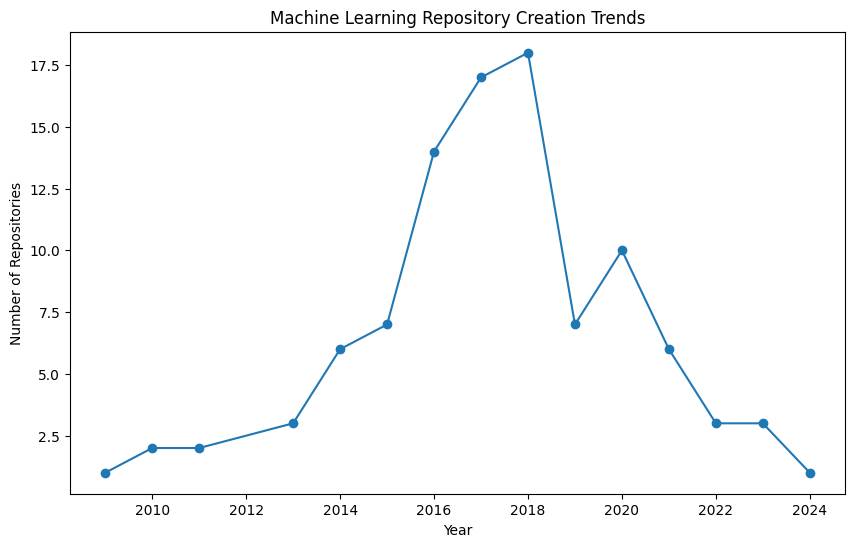

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(
    creation_trends["created_year"],
    creation_trends["repository_count"],
    marker="o"
)

plt.xlabel("Year")
plt.ylabel("Number of Repositories")
plt.title("Machine Learning Repository Creation Trends")

plt.show()

## Interpretation of Results

The results show that TensorFlow has the highest number of stars with 196,990 stars followed by Transformers with 164,195 stars.

Python is the most common language in the dataset with 30 repositories. Jupyter Notebook has 19 repositories and C++ has 12 repositories.

The number of repositories increased a lot between 2014 and 2018. The highest number was in 2018 with 18 repositories. After 2018 the number started to decrease.

Overall the results show that Machine Learning repositories are popular on GitHub and Python is the most common language in this dataset.


## Ethics Reflection

**Question 1: Why is it important to verify data collected from public APIs?**

It is important to verify the data to make sure it is correct and reliable before using it.

**Question 2: Why should data analysts document the source of their data?**

Data analysts should document the source so they know where the data came from and can check it later.

**Question 3: How can missing or inaccurate data affect data analysis and decision-making?**

Missing or inaccurate data can affect the results and can lead to wrong conclusions and decisions.


GitHub Repository
https://github.com/yomnaragab7/LV3-Second-Term-Project